Dataset shape: (150, 4)
Class distribution:
 species
0    50
1    50
2    50
Name: count, dtype: int64

First five rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

--- Multinomial Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



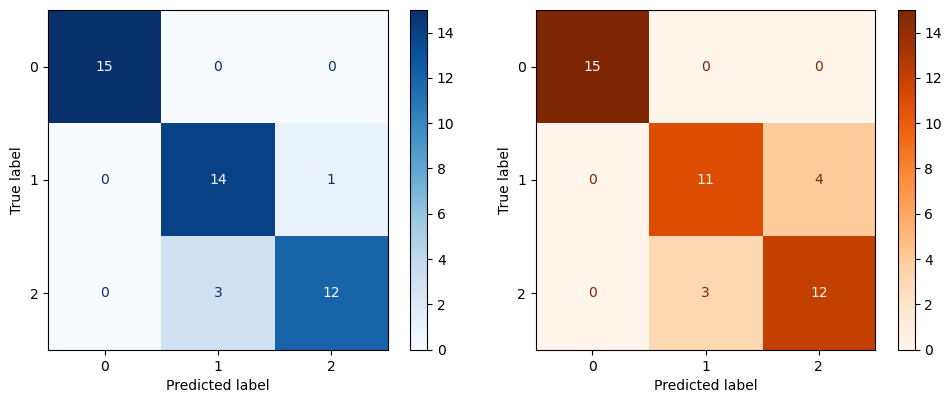

In [7]:
# Step 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

# Step 2. Load and explore dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print("\nFirst five rows:\n", X.head())

# Step 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 4. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5. Train models
# (a) Multinomial logistic regression
multi_clf = LogisticRegression(
    multi_class="multinomial", C=1.0, random_state=42
)
multi_clf.fit(X_train_scaled, y_train)

# (b) One-vs-Rest logistic regression
ovr_clf = LogisticRegression(
    multi_class="ovr",  max_iter=500, C=1.0, random_state=42
)
ovr_clf.fit(X_train_scaled, y_train)

# Step 6. Predictions
y_pred_multi = multi_clf.predict(X_test_scaled)
y_pred_ovr = ovr_clf.predict(X_test_scaled)

# Step 7. Evaluation
print("\n--- Multinomial Logistic Regression ---")
print(classification_report(y_test, y_pred_multi))
print("Accuracy:", accuracy_score(y_test, y_pred_multi))

print("\n--- One-vs-Rest Logistic Regression ---")
print(classification_report(y_test, y_pred_ovr, target_names=iris.target_names))
print("Accuracy:", accuracy_score(y_test, y_pred_ovr))

# Confusion matrices
cm_multi = confusion_matrix(y_test, y_pred_multi)
cm_ovr = confusion_matrix(y_test, y_pred_ovr)

# Step 8. Optional – GridSearchCV for best C in multinomial model
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    LogisticRegression(
        multi_class="multinomial", solver="lbfgs", max_iter=500, random_state=42
    ),
    param_grid,
    cv=5,
)
grid.fit(X_train_scaled, y_train)
print("\nBest C (multinomial):", grid.best_params_)
print("Best cross-val score:", grid.best_score_)

# Step 9. Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_multi).plot(ax=axes[0], cmap="Blues")
axes[0]

ConfusionMatrixDisplay(cm_ovr).plot(ax=axes[1], cmap="Oranges")
axes[1]

plt.tight_layout()
plt.show()
